In [6]:
from pandas.core.interchange import column
%reset -f

In [7]:
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
# import scienceplots
from src.optimization.core import load_optimization_results

In [4]:
# plt.style.use('science')

In [9]:
sol_df, sol_dict = load_optimization_results("MILP", "Sobol", 1)

Optimization results loaded from:
C:\Users\erdem\Documents\Studium\ModE_Group7\Erdem\results\MILP\Sobol\MILP_result_25_65_001.parquet
Metadata loaded from:
C:\Users\erdem\Documents\Studium\ModE_Group7\Erdem\results\MILP\Sobol\MILP_result_25_65_001.json


In [12]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def plot_unit_dispatch_and_demand(sol_df: pd.DataFrame, figsize=(14, 8)):
    """
    Zeigt die Leistungsabgabe aller Anlagen über die Zeit sowie die Nachfrage.
    Stellt die Leistungsabgabe gestapelt dar um zu sehen, wie der Bedarf gedeckt wird.
    """
    fig, axes = plt.subplots(2, 1, figsize=figsize, sharex=True)

    # WÄRME: Boiler + CHP + TES
    ax = axes[0]
    steps = sol_df['k']

    ax.bar(steps, sol_df['Q_out_B1'], label='Boiler 1', alpha=0.8)
    ax.bar(steps, sol_df['Q_out_B2'], bottom=sol_df['Q_out_B1'],
           label='Boiler 2', alpha=0.8)

    b_sum = sol_df['Q_out_B1'] + sol_df['Q_out_B2']
    ax.bar(steps, sol_df['Q_out_CHP1'], bottom=b_sum,
           label='CHP 1 (thermal)', alpha=0.8)

    chp_sum = sol_df['Q_out_CHP1'] + sol_df['Q_out_CHP2']
    ax.bar(steps, sol_df['Q_out_CHP2'], bottom=b_sum + chp_sum,
           label='CHP 2 (thermal)', alpha=0.8)

    # TES contribution (net)
    tes_net = sol_df['Q_out_TES'] - sol_df['Q_in_TES']
    tes_positive = tes_net.clip(lower=0)
    total_before_tes = b_sum + chp_sum
    ax.bar(steps, tes_positive, bottom=total_before_tes,
           label='TES (discharge)', alpha=0.8, color='orange')

    # Nachfrage
    ax.plot(steps, sol_df['Q_D'], 'r-', linewidth=2.5, label='Heat Demand', marker='o', markersize=3)

    ax.set_ylabel('Heat Power [kW]')
    ax.set_title('Heat Generation by Units vs. Demand')
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)

    # STROM: CHP + Grid
    ax = axes[1]
    ax.bar(steps, sol_df['P_out_CHP1'], label='CHP 1 (electrical)', alpha=0.8)
    ax.bar(steps, sol_df['P_out_CHP2'], bottom=sol_df['P_out_CHP1'],
           label='CHP 2 (electrical)', alpha=0.8)
    chp_elec_sum = sol_df['P_out_CHP1'] + sol_df['P_out_CHP2']
    ax.bar(steps, sol_df['P_grid'], bottom=chp_elec_sum,
           label='Grid Import', alpha=0.8)

    ax.plot(steps, sol_df['P_D'], 'r-', linewidth=2.5, label='Electricity Demand', marker='o', markersize=3)

    ax.set_xlabel('Time Step (h)')
    ax.set_ylabel('Electrical Power [kW]')
    ax.set_title('Electricity Generation by Units vs. Demand')
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    return fig


def plot_unit_on_off_status(sol_df: pd.DataFrame, figsize=(14, 6)):
    """
    Zeigt, welche Anlage zu welchem Zeitschritt aktiv (an/aus) ist.
    Nur die Einheiten mit delta=1 sind eingeschaltet.
    """
    fig, ax = plt.subplots(figsize=figsize)

    steps = sol_df['k']
    unit_names = ['Boiler 1', 'Boiler 2', 'CHP 1', 'CHP 2']
    delta_cols = ['delta_B1', 'delta_B2', 'delta_CHP1', 'delta_CHP2']
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

    for i, (unit, col, color) in enumerate(zip(unit_names, delta_cols, colors)):
        # Offset für bessere Lesbarkeit
        offset = i * 0.8
        ax.scatter(steps[sol_df[col] > 0.5], np.full_like(steps[sol_df[col] > 0.5], offset),
                  s=50, color=color, label=unit, zorder=3)

    ax.set_xlabel('Time Step (h)')
    ax.set_ylabel('Unit')
    ax.set_title('Unit On/Off Status Over Time')
    ax.set_yticks(np.arange(len(unit_names)) * 0.8)
    ax.set_yticklabels(unit_names)
    ax.grid(True, axis='x', alpha=0.3)
    ax.legend(loc='upper right')
    ax.set_ylim(-0.5, len(unit_names) * 0.8 - 0.3)

    plt.tight_layout()
    return fig


def plot_tes_state(sol_df: pd.DataFrame, figsize=(12, 5)):
    """
    Zeigt den Ladezustand des Wärmespeichers (TES) über die Zeit.
    """
    fig, ax = plt.subplots(figsize=figsize)

    steps = sol_df['k']
    ax.fill_between(steps, 0, sol_df['E_TES'], alpha=0.3, color='blue', label='TES Energy Content')
    ax.plot(steps, sol_df['E_TES'], 'b-', linewidth=2, label='TES Energy Level')

    # Nominal capacity line
    E_nom = 1000
    ax.axhline(y=E_nom, color='r', linestyle='--', linewidth=1.5, label='Nominal Capacity')

    ax.set_xlabel('Time Step (h)')
    ax.set_ylabel('Energy Content [kWh]')
    ax.set_title('Thermal Energy Storage (TES) State Over Time')
    ax.legend()
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    return fig


def plot_unit_power_output_individual(sol_df: pd.DataFrame, figsize=(14, 8)):
    """
    Zeigt die Leistungsabgabe jeder Anlage einzeln über die Zeit.
    """
    fig, axes = plt.subplots(2, 2, figsize=figsize, sharex=True)
    axes = axes.flatten()

    steps = sol_df['k']

    # Boiler 1
    ax = axes[0]
    ax.fill_between(steps, 0, sol_df['Q_out_B1'], alpha=0.5, color='blue')
    ax.plot(steps, sol_df['Q_out_B1'], 'b-', linewidth=2, label='Heat Output')
    ax.scatter(steps[sol_df['delta_B1'] > 0.5], sol_df['Q_out_B1'][sol_df['delta_B1'] > 0.5],
              color='blue', s=20, zorder=3, label='Status: On')
    ax.set_title('Boiler 1 - Heat Output')
    ax.set_ylabel('Power [kW]')
    ax.legend()
    ax.grid(True, alpha=0.3)

    # Boiler 2
    ax = axes[1]
    ax.fill_between(steps, 0, sol_df['Q_out_B2'], alpha=0.5, color='orange')
    ax.plot(steps, sol_df['Q_out_B2'], color='orange', linewidth=2, label='Heat Output')
    ax.scatter(steps[sol_df['delta_B2'] > 0.5], sol_df['Q_out_B2'][sol_df['delta_B2'] > 0.5],
              color='orange', s=20, zorder=3, label='Status: On')
    ax.set_title('Boiler 2 - Heat Output')
    ax.set_ylabel('Power [kW]')
    ax.legend()
    ax.grid(True, alpha=0.3)

    # CHP 1
    ax = axes[2]
    ax.bar(steps, sol_df['Q_out_CHP1'], alpha=0.5, label='Thermal Output', color='green')
    ax.plot(steps, sol_df['P_out_CHP1'], 'r-', linewidth=2, label='Electrical Output')
    ax.set_title('CHP 1 - Thermal & Electrical Output')
    ax.set_xlabel('Time Step (h)')
    ax.set_ylabel('Power [kW]')
    ax.legend()
    ax.grid(True, alpha=0.3)

    # CHP 2
    ax = axes[3]
    ax.bar(steps, sol_df['Q_out_CHP2'], alpha=0.5, label='Thermal Output', color='purple')
    ax.plot(steps, sol_df['P_out_CHP2'], 'r-', linewidth=2, label='Electrical Output')
    ax.set_title('CHP 2 - Thermal & Electrical Output')
    ax.set_xlabel('Time Step (h)')
    ax.set_ylabel('Power [kW]')
    ax.legend()
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    return fig


def plot_gas_and_grid_consumption(sol_df: pd.DataFrame, figsize=(12, 5)):
    """
    Zeigt den Gas- und Strombezug über die Zeit.
    """
    fig, ax = plt.subplots(figsize=figsize)

    steps = sol_df['k']
    gas_input = sol_df['Q_in_B1'] + sol_df['Q_in_B2'] + sol_df['Q_in_CHP1'] + sol_df['Q_in_CHP2']

    ax.bar(steps, gas_input, label='Total Gas Input', alpha=0.7, color='brown')
    ax.bar(steps, sol_df['P_grid'], bottom=gas_input, label='Grid Electricity Import', alpha=0.7, color='gray')

    ax.set_xlabel('Time Step (h)')
    ax.set_ylabel('Energy Input [kW]')
    ax.set_title('Total Gas and Electricity Consumption')
    ax.legend()
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    return fig



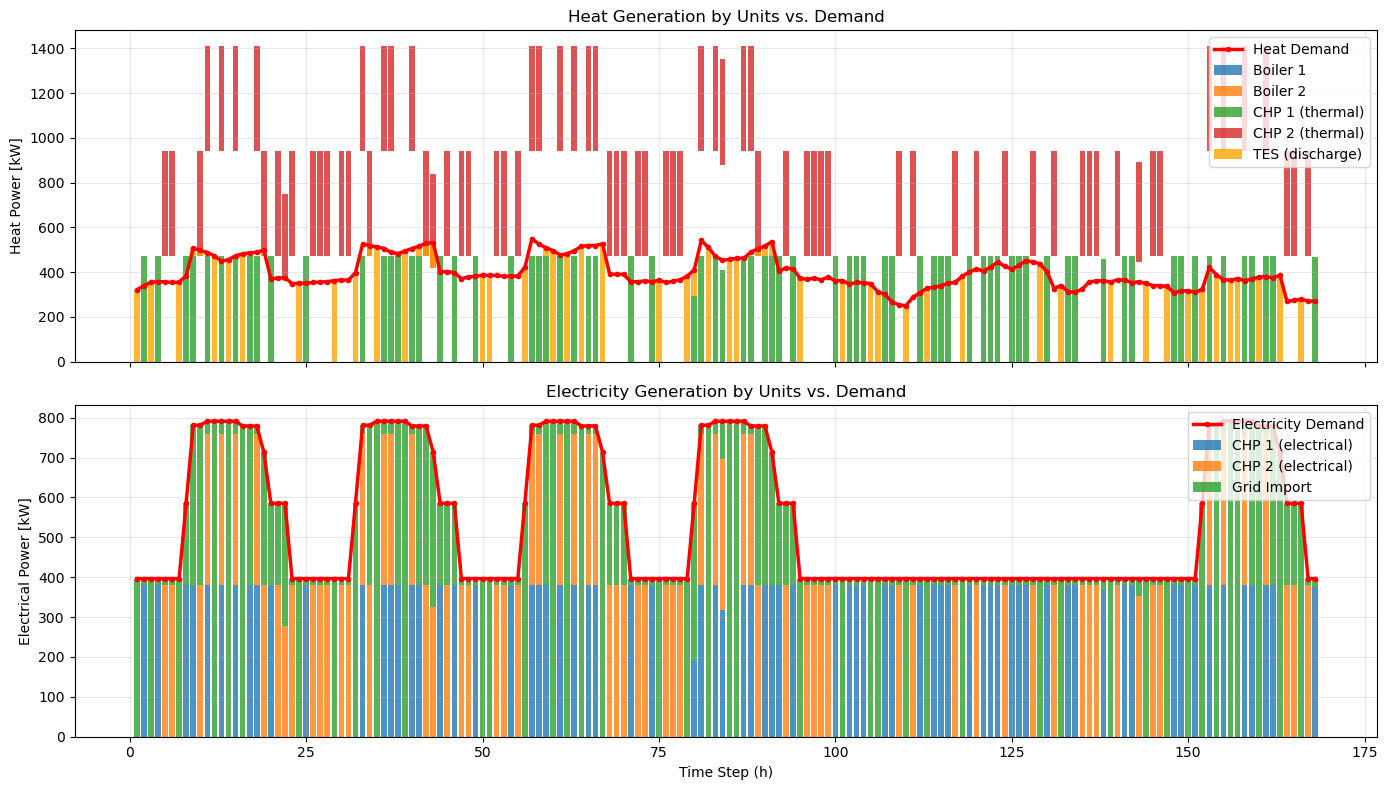

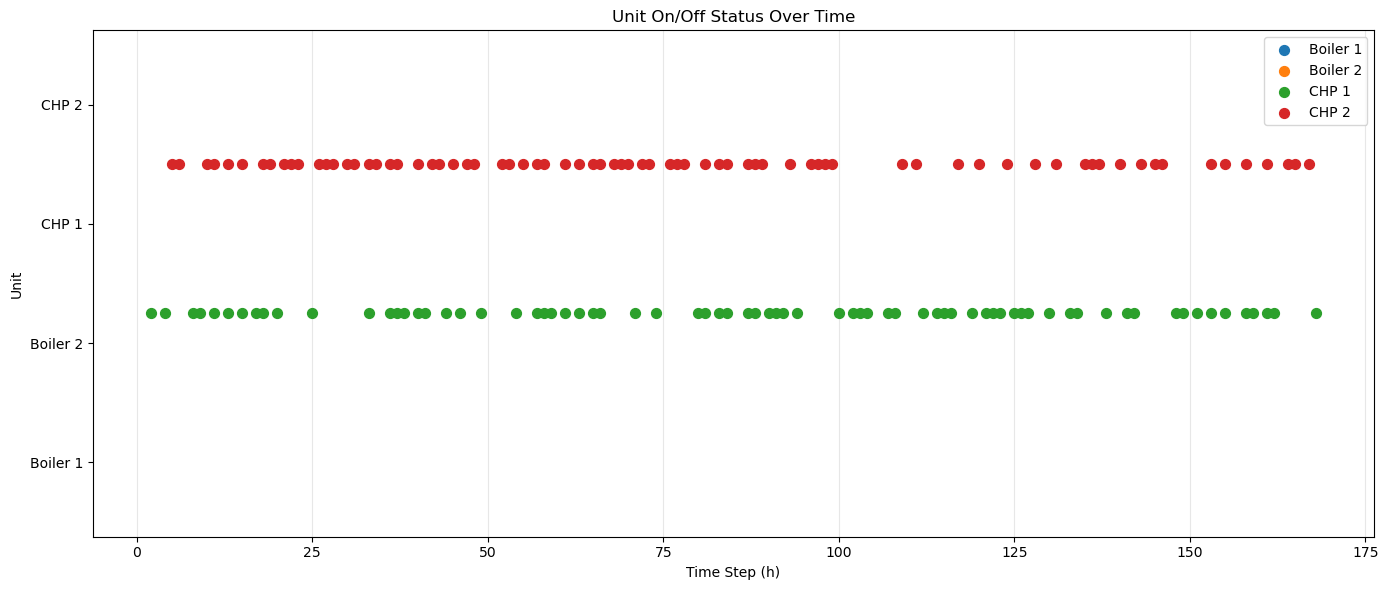

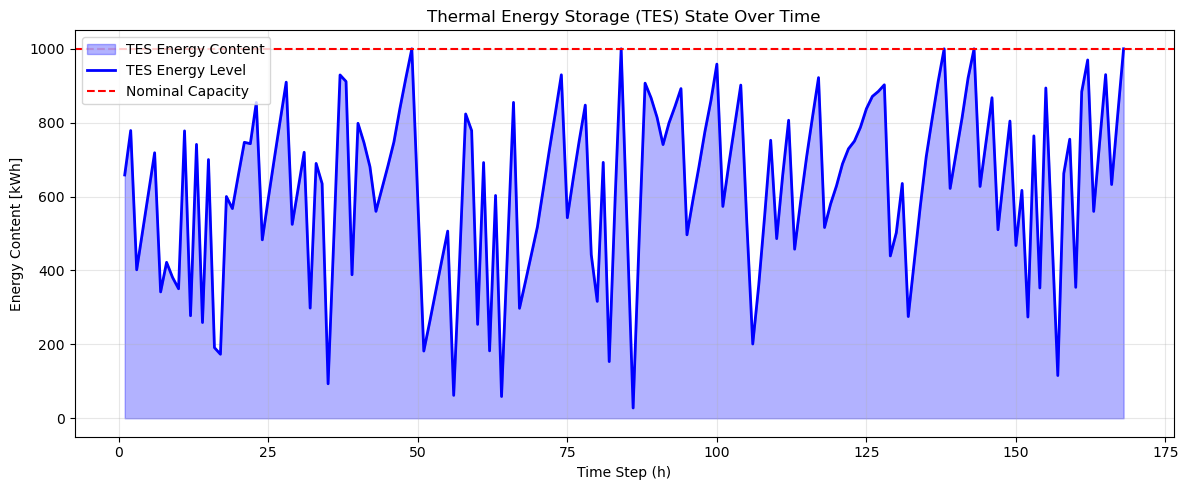

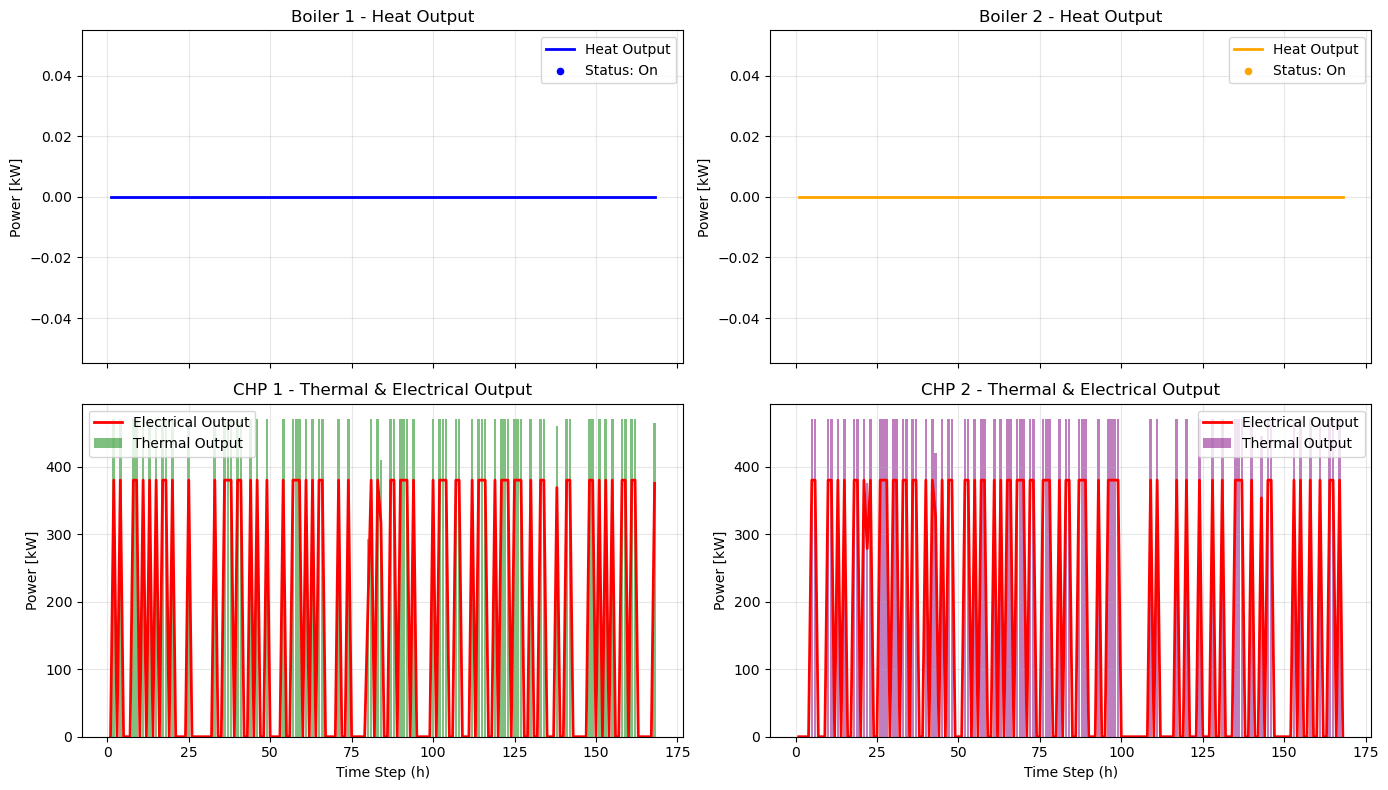

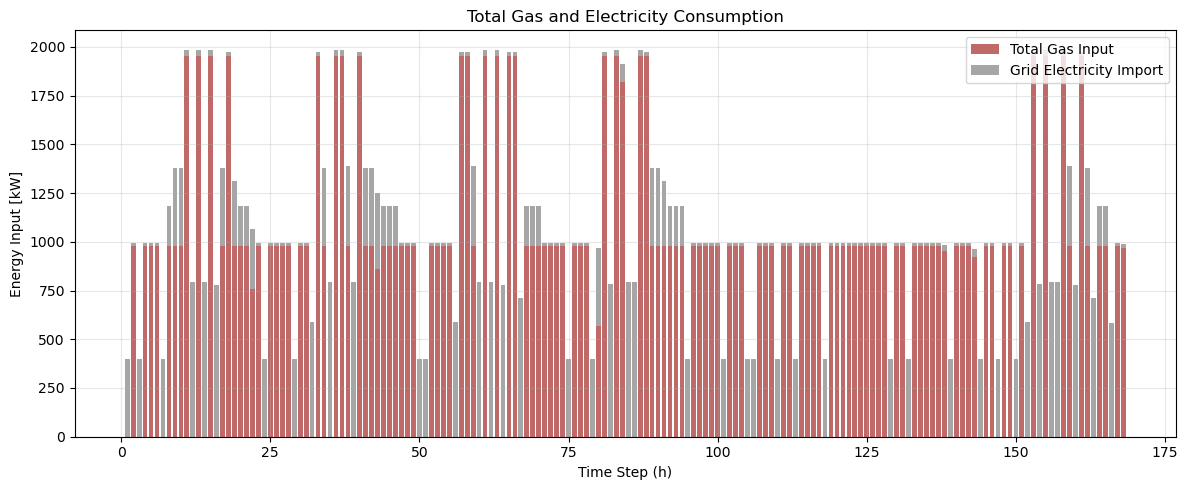

In [13]:
# Erstelle die Plots
fig1 = plot_unit_dispatch_and_demand(sol_df)
fig2 = plot_unit_on_off_status(sol_df)
fig3 = plot_tes_state(sol_df)
fig4 = plot_unit_power_output_individual(sol_df)
fig5 = plot_gas_and_grid_consumption(sol_df)

plt.show()

In [14]:
sol_df["E_TES"].iloc[-1]

np.float64(1000.0)

In [7]:
def plot_dispatch_results_compact(
    sol_df: pd.DataFrame,
    sol_dict: dict | None = None,
    output_path: str | None = None,
    fontsize: int = 10,
):
    """
    Erstellt ein kompaktes Dashboard mit Dispatching-Übersicht und Energieflüssen.
    Basiert auf der Freund-Funktion, adaptiert für sol_df und sol_dict.

    :param sol_df: Solution DataFrame mit allen Zeitseriendaten
    :param sol_dict: Metadata dictionary (optional, für OPEX und Preise)
    :param output_path: Pfad zum Speichern der Grafik (optional)
    :param fontsize: Schriftgröße
    :return: Figure und Axes-Array
    """
    from matplotlib.patches import Patch
    from pathlib import Path

    fs_tick     = fontsize
    fs_label    = fontsize
    fs_title    = round(fontsize * 1.1)
    fs_legend   = max(fontsize - 1, 7)
    fs_suptitle = round(fontsize * 1.4)

    # Extrahiere Preise und OPEX aus Metadaten
    gas_price = sol_dict.get("gas_price", 0.0) if sol_dict else 0.0
    el_price = sol_dict.get("electricity_price", 0.0) if sol_dict else 0.0
    opex = sol_dict.get("objective_value", None) if sol_dict else None

    k = sol_df["k"].to_numpy()

    # Binäre On/Off-Status-Matrix
    on_matrix = np.vstack([
        (sol_df["delta_B1"].to_numpy() > 0.5).astype(float),
        (sol_df["delta_B2"].to_numpy() > 0.5).astype(float),
        (sol_df["delta_CHP1"].to_numpy() > 0.5).astype(float),
        (sol_df["delta_CHP2"].to_numpy() > 0.5).astype(float),
    ])

    fig, axes = plt.subplots(4, 1, figsize=(18, 12), sharex=True)

    # 1) Unit Commitment Timeline (Heatmap)
    axes[0].imshow(
        on_matrix,
        aspect="auto",
        interpolation="nearest",
        cmap="YlGn",
        vmin=0,
        vmax=1,
        extent=[k[0] - 0.5, k[-1] + 0.5, -0.5, 3.5],
        origin="lower",
    )
    axes[0].set_yticks([0, 1, 2, 3])
    axes[0].set_yticklabels(["Boiler 1", "Boiler 2", "CHP 1", "CHP 2"], fontsize=fs_tick)
    axes[0].tick_params(labelsize=fs_tick)
    axes[0].set_title("Unit Commitment (On/Off)", fontsize=fs_title)
    axes[0].set_ylabel("Units", fontsize=fs_label)
    axes[0].legend(
        handles=[
            Patch(facecolor="#ffffe5", edgecolor="black", label="Off"),
            Patch(facecolor="#238443", edgecolor="black", label="On"),
        ],
        loc="upper left",
        bbox_to_anchor=(1.01, 1),
        borderaxespad=0,
        title="Status",
        fontsize=fs_legend,
    )

    # 2) TES Operation (Laden/Entladen + Speicherzustand)
    axes[1].bar(k, sol_df["Q_out_TES"], width=0.9, label="TES discharge [kW]",
                color="#2C7FB8", alpha=0.9)
    axes[1].bar(k, -sol_df["Q_in_TES"], width=0.9, label="TES charge [kW]",
                color="#EF3B2C", alpha=0.7)
    axes[1].plot(k, sol_df["E_TES"], color="#6A3D9A", linewidth=2.0,
                 label="TES stored energy [kWh]")
    axes[1].axhline(0.0, color="black", linewidth=0.9)
    axes[1].set_ylabel("TES output power [kW]\n/ stored energy [kWh]", fontsize=fs_label)
    axes[1].set_title("TES Operation", fontsize=fs_title)
    axes[1].tick_params(labelsize=fs_tick)
    axes[1].grid(True, axis="y", linestyle=":", linewidth=0.8, alpha=0.7)
    axes[1].legend(loc="upper left", bbox_to_anchor=(1.01, 1), borderaxespad=0, fontsize=fs_legend)

    # 3) Elektrisches Angebot Mix (Grid + CHP)
    p_chp_total = sol_df["P_out_CHP1"] + sol_df["P_out_CHP2"]
    axes[2].fill_between(k, 0, sol_df["P_grid"], step="mid", alpha=0.45, color="#FDAE61",
                         label="Grid import")
    axes[2].plot(k, p_chp_total, color="#1B9E77", linewidth=2, label="CHP electrical output")
    axes[2].plot(k, sol_df["P_D"], color="#111111", linewidth=1.7, linestyle="--",
                 label="Electrical demand")
    axes[2].set_title("Electrical Supply Mix", fontsize=fs_title)
    axes[2].set_ylabel("Power [kW]", fontsize=fs_label)
    axes[2].tick_params(labelsize=fs_tick)
    axes[2].grid(True, linestyle=":", linewidth=0.8, alpha=0.7)
    axes[2].legend(loc="upper left", bbox_to_anchor=(1.01, 1), borderaxespad=0, fontsize=fs_legend)

    # 4) Wärmeangebot und Gas-Einsatz
    q_boiler_total = sol_df["Q_out_B1"] + sol_df["Q_out_B2"]
    q_chp_total = sol_df["Q_out_CHP1"] + sol_df["Q_out_CHP2"]
    q_tes_net = sol_df["Q_out_TES"] - sol_df["Q_in_TES"]
    q_gas_total = sol_df["Q_in_B1"] + sol_df["Q_in_B2"] + sol_df["Q_in_CHP1"] + sol_df["Q_in_CHP2"]

    axes[3].plot(k, q_boiler_total, color="#E31A1C", linewidth=1.8, label="Boiler heat output")
    axes[3].plot(k, q_chp_total, color="#FF7F00", linewidth=1.8, label="CHP heat output")
    axes[3].plot(k, q_tes_net, color="#2C7FB8", linewidth=1.8, label="TES net heat (discharge-charge)")
    axes[3].plot(k, sol_df["Q_D"], color="#111111", linewidth=1.7, linestyle="--", label="Heat demand")
    axes[3].bar(k, q_gas_total, width=0.85, alpha=0.22, color="#33A02C",
                label="Gas purchased (fuel input)")
    axes[3].set_title("Heat Supply and Gas Purchase", fontsize=fs_title)
    axes[3].set_ylabel("Heat flow / Gas input [kW]", fontsize=fs_label)
    axes[3].set_xlabel("Time step k [-]", fontsize=fs_label)
    axes[3].tick_params(labelsize=fs_tick)
    axes[3].grid(True, linestyle=":", linewidth=0.8, alpha=0.7)
    axes[3].legend(loc="upper left", bbox_to_anchor=(1.01, 1), borderaxespad=0, fontsize=fs_legend)

    # Titel mit Preisen und OPEX
    _title = f"Operational Dispatch Overview — gas={gas_price:.3f} €/kWh, el={el_price:.3f} €/kWh"
    if opex is not None:
        ratio_str = f"   |   c_G/c_el = {gas_price/el_price:.3f}" if el_price != 0 else ""
        _title += f"\nTotal OPEX: {opex:,.2f} €{ratio_str}"

    fig.suptitle(_title, fontsize=fs_suptitle, y=0.99)

    # Speichern falls Pfad gegeben
    if output_path is not None:
        output_file = Path(output_path)
        output_file.parent.mkdir(parents=True, exist_ok=True)
        fig.tight_layout()
        fig.subplots_adjust(right=0.78, top=0.92)
        fig.savefig(output_file, dpi=150)
        print(f"Dispatch overview saved to {output_file}")
        plt.close(fig)
    else:
        fig.tight_layout()
        fig.subplots_adjust(right=0.78, top=0.92)

    return fig, axes

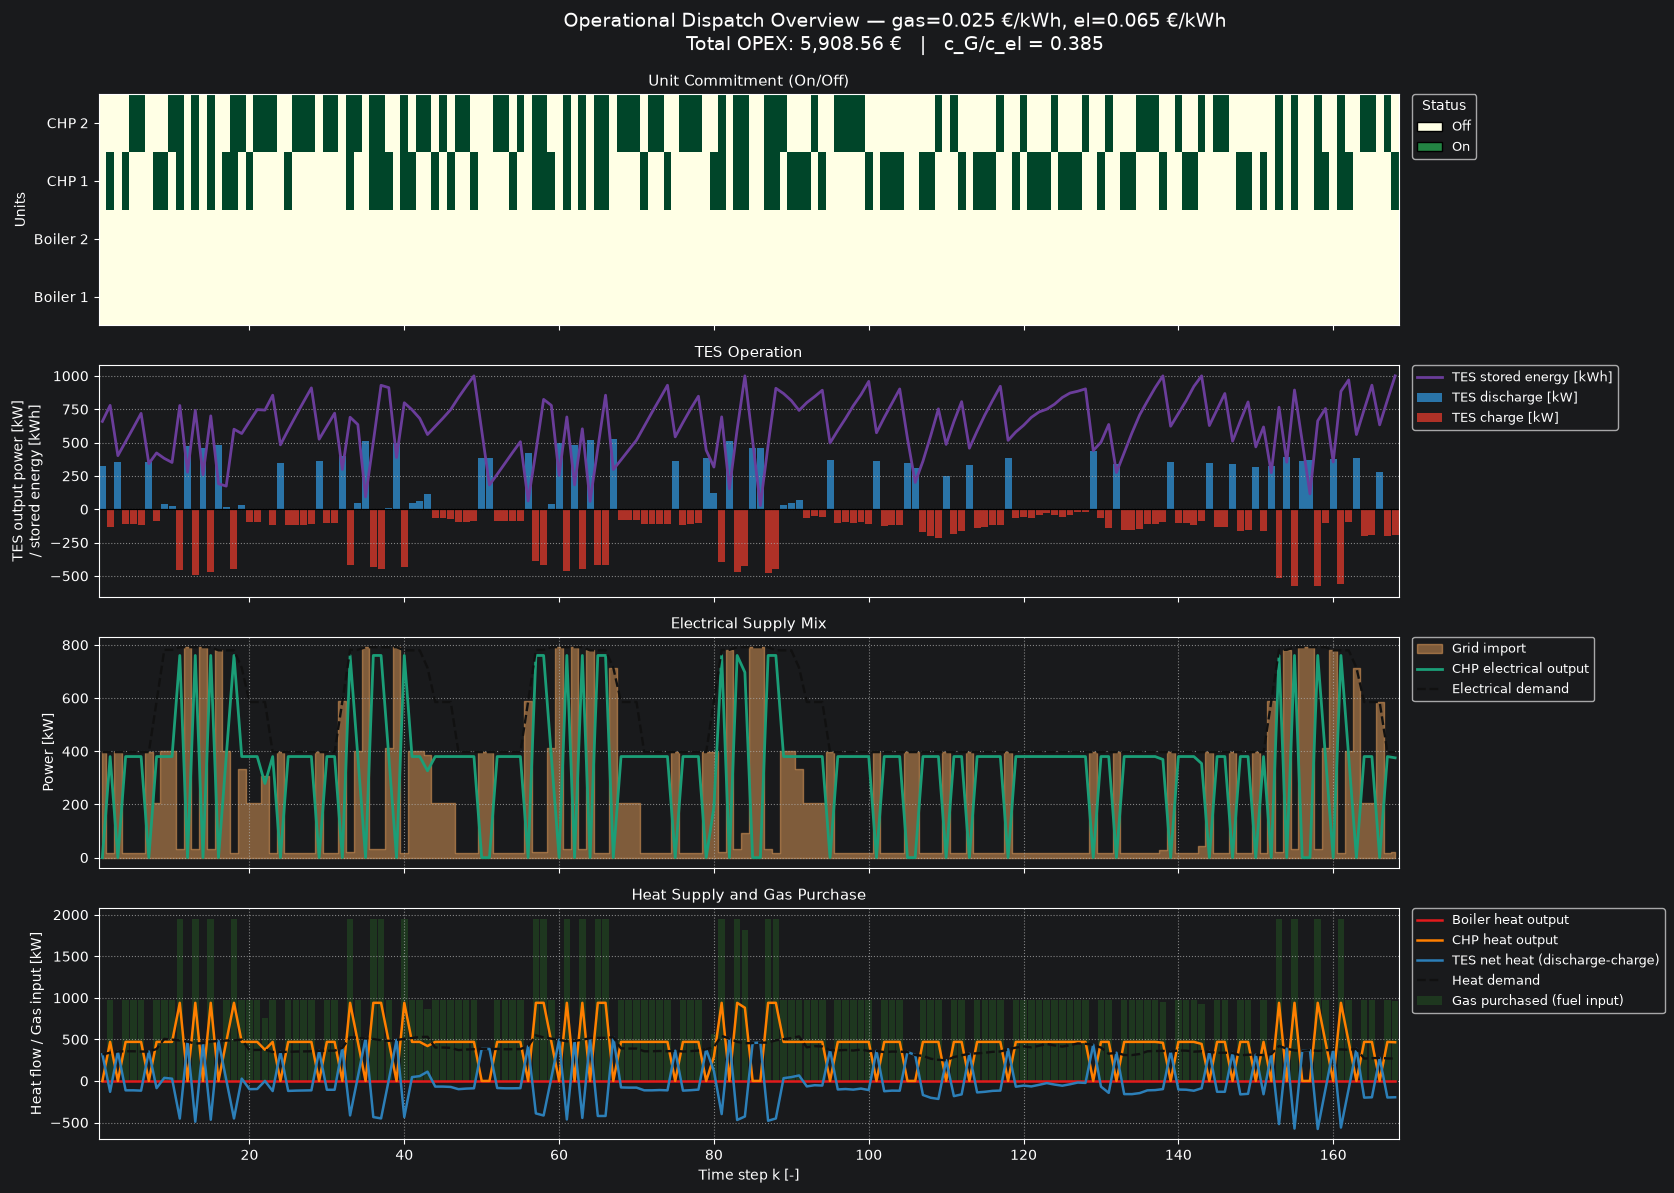

In [8]:
# Mit Speichern
# fig, axes = plot_dispatch_results_compact(
#     sol_df,
#     sol_dict,
#     output_path="Erdem/visualization/dispatch_overview_MILP.png",
#     fontsize=10
# )

# Oder nur zum Anzeigen
fig, axes = plot_dispatch_results_compact(sol_df, sol_dict, fontsize=10)
plt.show()

In [47]:
gas_prices = np.array([25.0, 315.0]) # €/MWh
electr_prices = np.array([65.0, 450.0]) # €/MWh

ratio_matrix = gas_prices[:, None] / electr_prices[None, :]

min_ratio = ratio_matrix.min()
max_ratio = ratio_matrix.max()

print(f"Min ratio: {min_ratio:.3f}\nMax ratio: {max_ratio:.3f}")

Min ratio: 0.056
Max ratio: 4.846


In [51]:
log_samples = np.logspace(np.log10(min_ratio), np.log10(max_ratio), 40)

In [57]:
samples = pd.Series(log_samples, name="ratios")

In [58]:
samples

0     0.055556
1     0.062300
2     0.069863
3     0.078345
4     0.087856
5     0.098522
6     0.110482
7     0.123895
8     0.138936
9     0.155802
10    0.174717
11    0.195928
12    0.219713
13    0.246387
14    0.276298
15    0.309841
16    0.347456
17    0.389637
18    0.436939
19    0.489984
20    0.549468
21    0.616174
22    0.690978
23    0.774863
24    0.868932
25    0.974421
26    1.092716
27    1.225372
28    1.374133
29    1.540954
30    1.728026
31    1.937810
32    2.173061
33    2.436871
34    2.732709
35    3.064461
36    3.436489
37    3.853680
38    4.321519
39    4.846154
Name: ratios, dtype: float64